In [1]:
from tapas_gmm.dataset.scene import SceneDataset
from pathlib import Path
from tapas_gmm.dataset.bc import BCDataset, BCDataConfig
from torch.utils.data import DataLoader
from tapas_gmm.utils.observation import collate
from tapas_gmm.dataset.demos import Demos

from tapas_gmm.policy.models.tpgmm import (
    AutoTPGMM,
    AutoTPGMMConfig,
    TPGMMConfig,
    FrameSelectionConfig,
    DemoSegmentationConfig,
    InitStrategy,
    FittingStage,
)

2026-06-15 23:50:56.857 | INFO     |  Running on cpu


/home/nils/Documents/Study Project/Code/riepybdlib/riepybdlib/data.py:34: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_listdir


In [2]:
data_root = Path("../outputs/bimanual_dataset")

In [3]:
loaded_dataset = SceneDataset(
    data_root=Path(data_root)
)

2026-06-15 23:50:58.843 | INFO     |  Initializing datasete using ../outputs/bimanual_dataset/metadata.json
2026-06-15 23:50:58.845 | INFO     |  Extracted gt object labels []
2026-06-15 23:50:58.845 | INFO     |  Extracted tsdf object labels []


In [4]:
bc_config = BCDataConfig(
    fragment_length = -1,
    cameras = tuple(),
)

bc_dataset = BCDataset(
    scene_dataset=loaded_dataset,
    config=bc_config,
)

2026-06-15 23:50:58.855 | INFO     |  Initializing BCDataset:
2026-06-15 23:50:58.855 | INFO     |    Training on fragments of length -1.
2026-06-15 23:50:58.855 | INFO     |    Loading raw data for encoder.


In [5]:
loader = DataLoader(
    bc_dataset,
    collate_fn=collate,
)

In [6]:
trajs = []

for traj in loader:
    trajs.append(traj[0])

In [7]:
demos = Demos(trajectories = trajs)


2026-06-15 23:50:59.563 | INFO     |  Subsampling to length 104 using strategy mean-length.


In [8]:
tpgmm_config = TPGMMConfig(
    add_time_component = True,
)

segmentation_config = DemoSegmentationConfig(
    distance_based = False,
    velocity_based = True,
)

auto_config = AutoTPGMMConfig(
    tpgmm=tpgmm_config,
    demos_segmentation=segmentation_config,
)


In [9]:
model = AutoTPGMM(auto_config)

2026-06-15 23:50:59.610 | INFO     |  Fitting AutoTPGMM
2026-06-15 23:50:59.610 | INFO     |  Performing fitting actions: [INIT, EM_HMM]
2026-06-15 23:50:59.610 | INFO     |  Segmenting trajectories


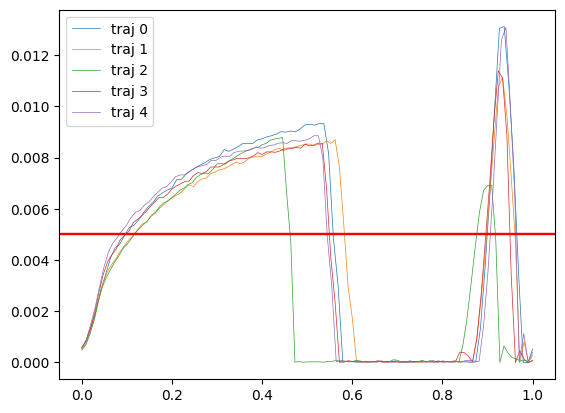

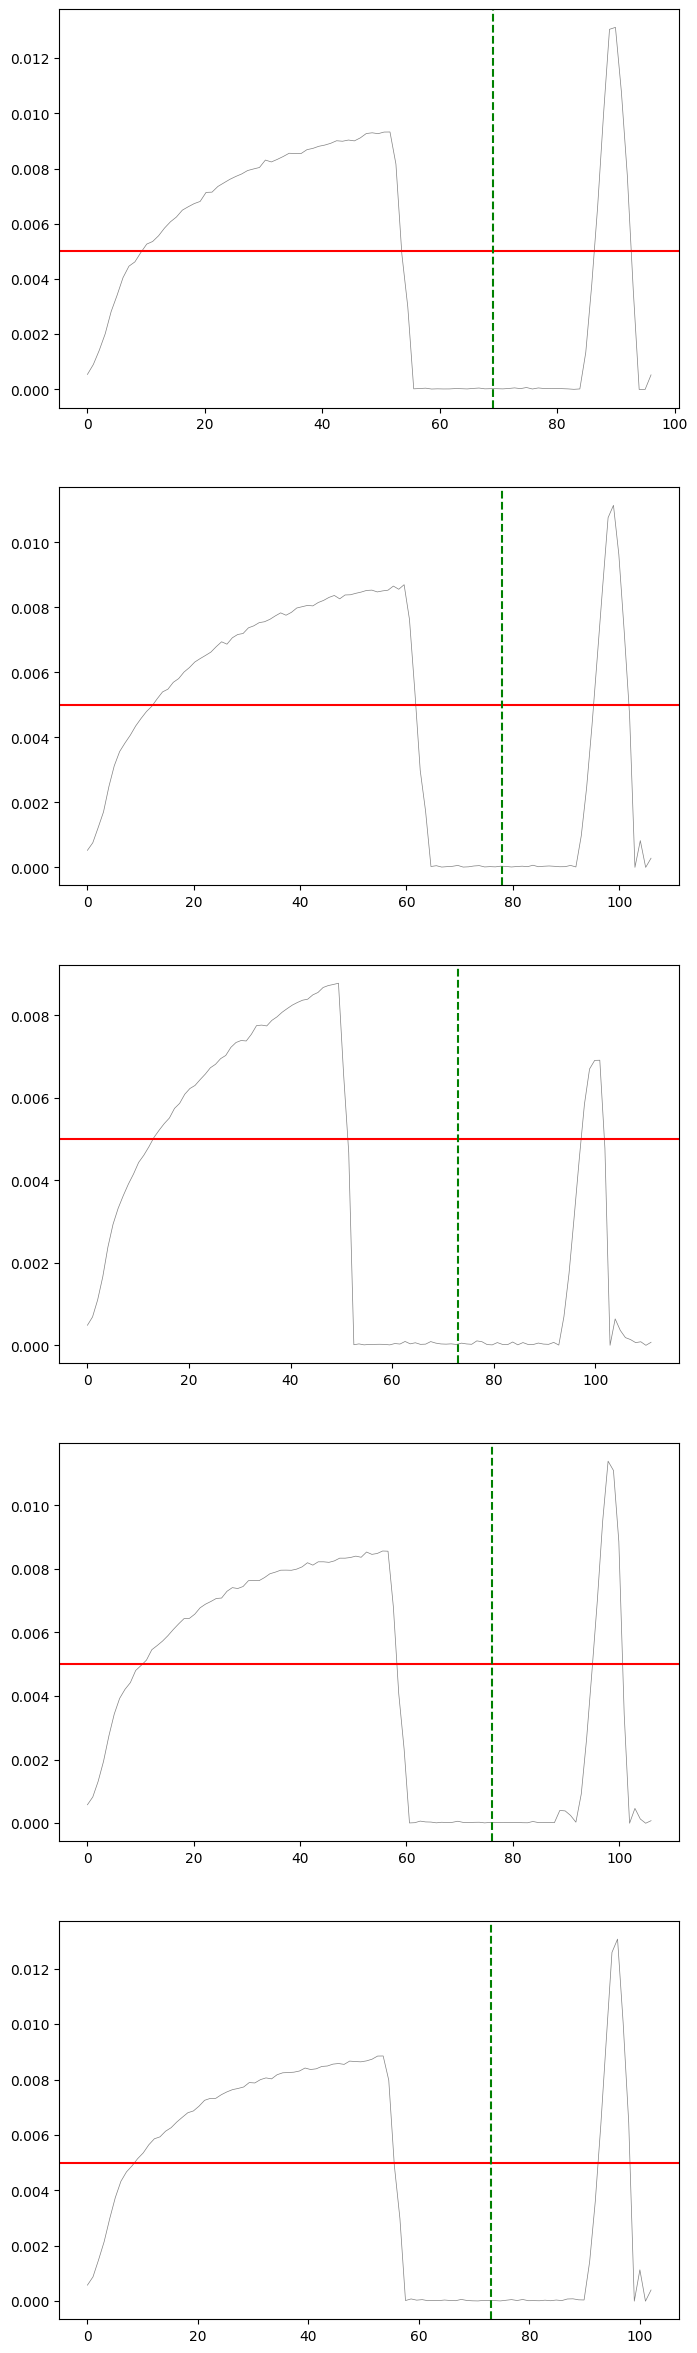

2026-06-15 23:51:00.328 | INFO     |  Creating segement of demos.


AttributeError: 'Demos' object has no attribute 'world2frames'

In [10]:
lik, avg_loglik = model.fit_trajectories(
    demos = demos,
    fitting_actions = [ 
        FittingStage.INIT,
        FittingStage.EM_HMM,
    ],
)